In [1]:
import matplotlib
from datascience import *
%matplotlib inline
import matplotlib.pyplot as plots
import numpy as np
plots.style.use('fivethirtyeight')

## Central Limit Theorem (CLT)


### Distribution of the Sample Average

We look at the distribution of the average of several samples. </br>
If the sample size is large enough, the distribution will be roughly normal. 


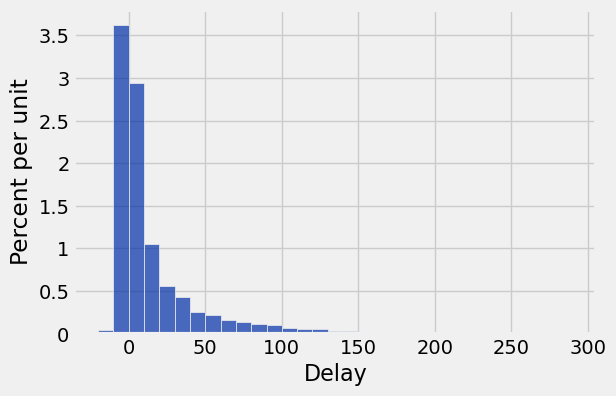

In [2]:
united = Table.read_table('united.csv')
united_bins = np.arange(-20, 300, 10)
united.hist('Delay', bins=united_bins)

In [3]:
def one_sample_mean(sample_size):
    """Take a sample from the population of flights and compute its mean"""
    sampled_flights = united.sample(sample_size)
    return np.mean(sampled_flights.column('Delay'))

In [4]:
def ten_thousand_sample_means(sample_size):
    """Use the bootstrap to approximate the distribution of the sample mean"""
    means = make_array()
    for i in np.arange(10000):
        mean = one_sample_mean(sample_size)
        means = np.append(means, mean)
    return means

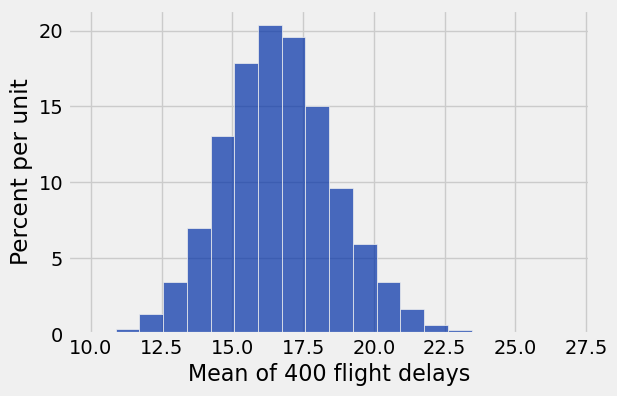

In [5]:
sample_means_400 = ten_thousand_sample_means(400)
Table().with_column('Mean of 400 flight delays', sample_means_400).hist(bins=20)

In [6]:
united.num_rows

13825

In [7]:
# QUESTION: How many possible sample means are there?
united.num_rows ** 400

1845253300060122534684058597421182951017338738756884128476156537109395559702295050837795610986469015706417701209704203890696502616877632733167737247128710898267622177602279004150237321497531712957437744194467949953310673085563343687922543234838511385550568262088418334016217887061735745358842456577208939555740404373614633941136938352510678553686140728842897559436843191863609514780562396147921834537075860636817493656816017587537752125750151805566479543166742758254440594398100342650860455445795087942680221047750947255562969782801791748639952850756659518870235020316513575934561122027710440608023538776721761349403194150575014182981349346980577699633375066811153948871815566280319121565243984196831524157664160526536071758298269096548661601001356951548310460921171197940711389849058290284443729287317331793254191518876765178731748453564076631795997590039640387156475975294002056115371653663653810384491550154761367793765502453546587829476276348569091617961438914859251316410793595152416543512156519

### CLT: Center

The distribution of the sample average is roughly a bell
curve centered at the population average.

Population Average: 16.6581555154


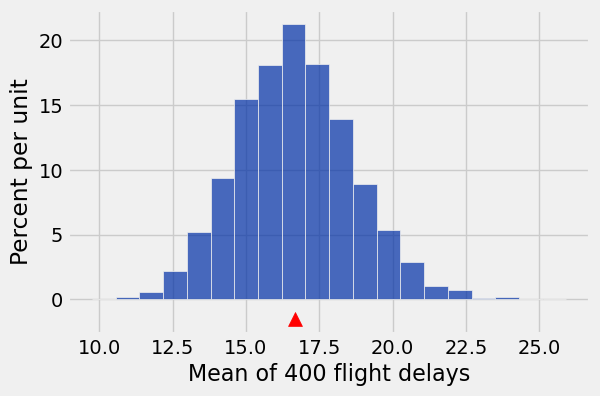

In [8]:
delay_mean = np.average(united.column('Delay'))
sample_means_400 = ten_thousand_sample_means(400)
Table().with_column('Mean of 400 flight delays', sample_means_400).hist(bins=20)

# This code plots the location of the population average. Do not Edit. 
plots.scatter(delay_mean, -0.015, marker='^', color='red', s=100)

# This code displays the population average as text above the histogram. 
print('Population Average:', delay_mean)

### CLT: Variability of the Sample Average

***AKA The Spread***

The Spread is important because:

* Along with the center, the spread helps identify exactly which normal curve is the distribution of the sample average.
* The variability of the sample average helps us measure how accurate the sample average is as an estimate of the population average.
* If we want a specified level of accuracy, understanding the variability of the sample average helps us work out how large our sample has to be
* The standard deviation is approximately equal to the standard deviation of the population


In [9]:
sample_means_900 = ten_thousand_sample_means(900)


In [10]:
means_tbl = Table().with_columns(
    '400', sample_means_400,
    '900', sample_means_900
)

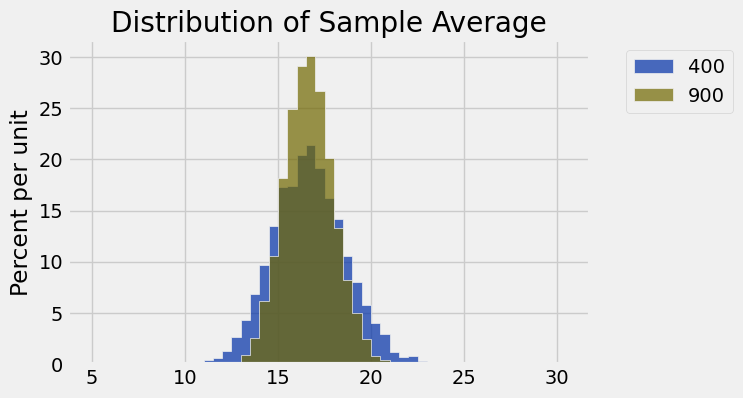

In [11]:
means_tbl.hist(bins = np.arange(5, 31, 0.5))
plots.title('Distribution of Sample Average');

### Discussion Question

The gold histogram shows the distribution of __________
values, each of which is ________________________.

Fill in the blanks with the choices below. Which belongs in each blank? </br>
(a) 900 </br>
(b) 10,000 </br>
(c) a randomly sampled flight delay </br>
(d) an average of flight delays

## Quantifying the Effect of Sample Size

In [12]:
delays = united.column('Delay')
delay_mean = np.mean(delays)
delay_sd = np.std(delays)
delay_mean, delay_sd

(16.658155515370705, 39.480199851609314)

In [13]:
"""Empirical distribution of random sample means"""

def plot_and_summarize_sample_means(sample_size):
    sample_means = ten_thousand_sample_means(sample_size)
    sample_means_tbl = Table().with_column('Sample Means', sample_means)
    
    # Print some information about the distribution of the sample means
    print("Sample size: ", sample_size)
    print("Population mean:", delay_mean)
    print("Average of sample means: ", np.mean(sample_means))
    print("\nPopulation SD:", delay_sd)
    print("SD of sample means:", np.std(sample_means))
    print("Ratio:", delay_sd / np.std(sample_means))

    # Plot a histogram of the sample means
    sample_means_tbl.hist(bins=20)
    plots.xlabel('Sample Means')
    plots.title('Sample Size ' + str(sample_size))

Sample size:  100
Population mean: 16.6581555154
Average of sample means:  16.682879

Population SD: 39.4801998516
SD of sample means: 3.9711261402
Ratio: 9.94181460316


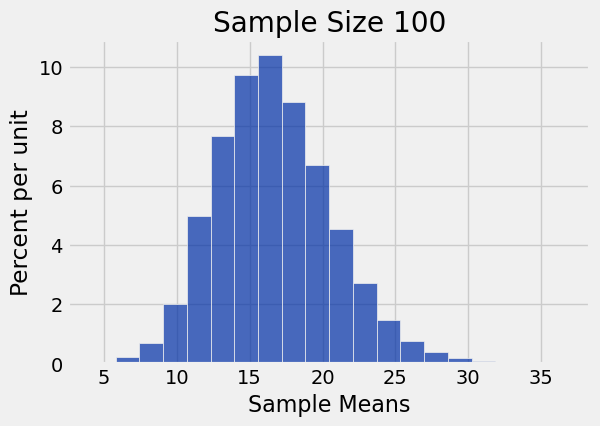

In [14]:
plot_and_summarize_sample_means(100)

Sample size:  400
Population mean: 16.6581555154
Average of sample means:  16.6506825

Population SD: 39.4801998516
SD of sample means: 1.98969981729
Ratio: 19.8422895295


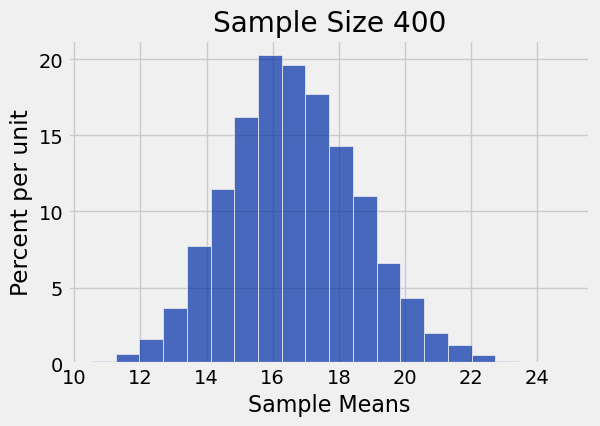

In [15]:
plot_and_summarize_sample_means(400)

Sample size:  900
Population mean: 16.6581555154
Average of sample means:  16.6737195556

Population SD: 39.4801998516
SD of sample means: 1.32216907576
Ratio: 29.8601749015


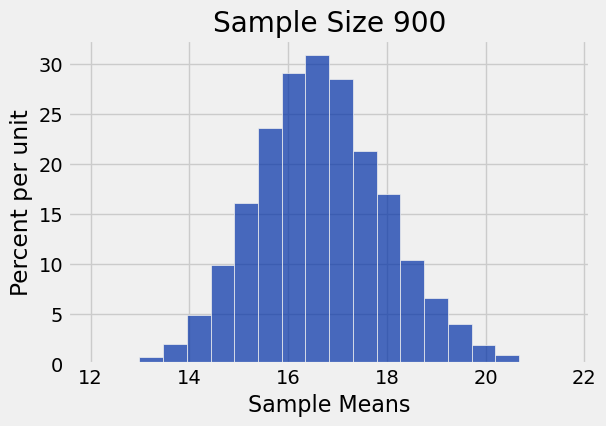

In [16]:
plot_and_summarize_sample_means(900)

***QUESTION: Compare the population mean and standard deviation to each sample mean and standard deviation. </br>
What do you notice?***

YOUR ANSWER HERE

### Central Limit Theorem

If the sample is large and drawn at random with replacement, </br>
Then, regardless of the distribution of the population, </br>

The probability distribution of the sample average: </br>

* is ... 
* mean = ... 
* SD = $\dfrac{\text{standard of pop}}{\sqrt{\text{sample size}}} = \dfrac{\sigma}{\sqrt{n}}$
    
***COMPLETE: Compute the Standard Deviation for each sample size directly below.***

In [17]:
# Sample size of 100

39.48 / np.sqrt(100)

3.9479999999999995

In [18]:
# Sample size of 400

39.48 / np.sqrt(400)

1.9739999999999998

In [19]:
# Sample size of 900

39.48 / np.sqrt(900)

1.3159999999999998

### Discussion Question
A population has average 70 and SD 10. One of the
histograms below is the empirical distribution of the
averages of 10,000 random samples of size 100 drawn
from the population. Which one?
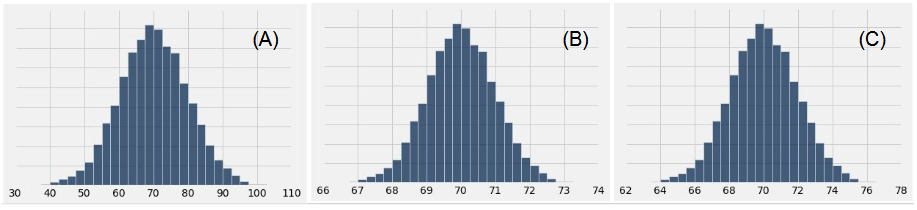

### Connecting to Confidence Intervals

For about ... of all samples, the sample average and population average are within 2 SDs of each other.</br>

Since the curve is approximately normal, the distance is ... . </br>

Total width of a 95% confidence interval for the population average:

= $\dfrac{4 * \text{SD of pop}}{\sqrt{\text{sample size}}}$

= $ 4 * \dfrac{\sigma}{\sqrt{n}}$
